# EDA — Acciones de Brasil

Universo: **BDRs brasileñas** (`dim_empresa.mercado='brasil'`, 12 tickers — se excluyen `NAT3D`/`VAL3D`, rotas en Yahoo: 404, sin precio ni métricas) **+ empresas brasileñas que cotizan como ADR directo en NYSE** (`mercado='usa_otros'`, `pais_origen='Brazil'`, 20 tickers: VALE, PBR, NU, ABEV, PAGS, BBD, ITUB, SUZ, TIMB, SBS, etc.) — 32 tickers en total.

**Ojo con los duplicados**: 4 empresas cotizan en los dos grupos a la vez (misma compañía, dos vehículos) — Itaú (`ITUB3`/`ITUB`), Suzano (`SUZB3`/`SUZ`), Tim (`TIMS3`/`TIMB`) y Sabesp (`SBSP3`/`SBS`). No se deduplican (cada uno puede tener liquidez/precio distinto), quedan marcados con la columna `duplica_de` para no contarlos dos veces sin darse cuenta al sacar conclusiones agregadas.

A diferencia del EDA general, acá el foco es la **exposición macro Brasil**, usando las series `USDBRL`/`BOVESPA` de `fact_macro_daily`:

- Las BDRs cotizan en B3 **en reales** (`fact_precios_daily` para `mercado='brasil'` está en BRL) — para ellas separamos cuánto del retorno es negocio real y cuánto es movimiento del tipo de cambio.
- Los ADR directos ya cotizan **en dólares** en NYSE — no les aplica ese ajuste (ya están "limpios" de ese efecto por definición), pero sí tiene sentido medir su correlación diaria contra `USDBRL`/`BOVESPA`, que es lo que se hace en la sección 5 para las 32 empresas.

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

con = duckdb.connect("../data/warehouse.duckdb", read_only=True)

bdr = con.execute("""
    SELECT * FROM dim_empresa
    WHERE mercado = 'brasil' AND ticker_usd NOT IN ('NAT3D', 'VAL3D')
""").fetchdf()
bdr["vehiculo"] = "BDR"

adr = con.execute("""
    SELECT * FROM dim_empresa
    WHERE mercado = 'usa_otros' AND pais_origen ILIKE '%brazil%'
""").fetchdf()
adr["vehiculo"] = "ADR directo"

# 4 empresas cotizan como BDR y como ADR a la vez (misma compañia, dos
# vehiculos) -- no se deduplican, quedan marcadas para no contarlas dos
# veces sin querer en un promedio/conteo agregado.
DUPLICADOS = {
    "ITUB": "ITUB3", "ITUB3": "ITUB",
    "SUZ": "SUZB3", "SUZB3": "SUZ",
    "TIMB": "TIMS3", "TIMS3": "TIMB",
    "SBS": "SBSP3", "SBSP3": "SBS",
}

dim_brasil = pd.concat([bdr, adr], ignore_index=True)
dim_brasil["duplica_de"] = dim_brasil["ticker_usd"].map(DUPLICADOS)
BRASIL = dim_brasil["ticker_usd"].tolist()
BDR_TICKERS = bdr["ticker_usd"].tolist()  # subset en BRL -- usado en la seccion 4 (retorno limpio vs. cambiario)

metrics = con.execute("SELECT * FROM fact_metrics_daily WHERE ticker_usd = ANY(?)", [BRASIL]).fetchdf()
precios = con.execute(
    "SELECT * FROM fact_precios_daily WHERE ticker_usd = ANY(?) AND adj_close IS NOT NULL", [BRASIL]
).fetchdf()
macro_brasil = con.execute("SELECT * FROM fact_macro_daily WHERE serie IN ('USDBRL', 'BOVESPA')").fetchdf()

print(f"Universo: {len(BRASIL)} empresas brasileñas ({len(bdr)} BDR + {len(adr)} ADR directo, "
      f"{dim_brasil['duplica_de'].notna().sum()} marcadas como duplicado)")
print("dim_brasil:", dim_brasil.shape)
print("fact_metrics_daily:", metrics.shape)
print("fact_precios_daily:", precios.shape)
print("fact_macro_daily (USDBRL/BOVESPA):", macro_brasil.shape)

Universo: 32 empresas brasileñas (12 BDR + 20 ADR directo, 8 marcadas como duplicado)
dim_brasil: (32, 16)
fact_metrics_daily: (187, 29)
fact_precios_daily: (40436, 8)
fact_macro_daily (USDBRL/BOVESPA): (2556, 3)


## 1. Overview del subuniverso

32 empresas (BDR + ADR directo) — todavía manejable para mirarlas una por una en vez de agregarlas en gráficos de distribución como en el EDA general.

In [2]:
ultimo = metrics.sort_values("fecha").groupby("ticker_usd").last().reset_index()
overview = dim_brasil.merge(ultimo, on="ticker_usd")[
    ["ticker_usd", "nombre_empresa", "vehiculo", "duplica_de", "sector", "industria",
     "market_cap", "pe_trailing", "dividend_yield_pct"]
].sort_values("market_cap", ascending=False)
overview

,ticker_usd,nombre_empresa,vehiculo,duplica_de,sector,industria,market_cap,pe_trailing,dividend_yield_pct
2,ITUB3,Banco Itau Unibanco Sa,BDR,ITUB,Financial Services,Banks - Regional,5.391900e+11,11.82,0.45
0,BPA11,Banco Btg Pactual S.A,BDR,NaN,Financial Services,Capital Markets,2.224583e+11,107.52,1.40
11,WEGE3,Weg S.A,BDR,NaN,Industrials,Electrical Equipment & Parts,2.158754e+11,34.53,3.01
26,PBR,Petroleo Brasileiro S.A,ADR directo,NaN,Energy,Oil & Gas Integrated,1.395205e+11,5.47,7.74
1,BBAS3,Banco Do Brasil S.A,BDR,NaN,Financial Services,Banks - Regional,1.354145e+11,11.03,0.58
3,SBSP3,Cia De Saneamiento Basi,BDR,SBS,Utilities,Utilities - Regulated Water,9.927342e+10,12.01,2.46
23,ITUB,Itau Unibanco Holding Sa,ADR directo,ITUB3,Financial Services,Banks - Regional,9.467788e+10,11.01,1.99
24,NU,Nu Holdings Ltd/Cayman,ADR directo,NaN,Financial Services,Banks - Regional,6.487615e+10,18.40,0.00
31,VALE,Vale,ADR directo,NaN,Basic Materials,Other Industrial Metals & Mining,5.855930e+10,27.52,6.13
9,SUZB3,Suzano S.A,BDR,SUZ,Basic Materials,Paper & Paper Products,5.461971e+10,6.72,2.53


## 2. Valuación vs. sector (capa Gold)

`gold_comparables` ya compara cada empresa contra la mediana de su sector REAL (con `sector_corregido` aplicado donde Yahoo clasifica mal — ver `correcciones_sector.py`). Acá solo filtramos al subuniverso brasileño.

In [3]:
comparables_brasil = con.execute("SELECT * FROM gold_comparables WHERE ticker_usd = ANY(?)", [BRASIL]).fetchdf()

cols_comp = [
    "ticker_usd", "nombre_empresa", "sector", "pe_trailing", "comp_pe_mediana_sector", "comp_pe_vs_sector_pct",
    "margen_neto_pct", "comp_margen_vs_sector_pp", "crecimiento_ingresos_anual_pct", "comp_percentil_crecimiento_en_sector",
]
comparables_brasil[cols_comp].sort_values("comp_pe_vs_sector_pct")

,ticker_usd,nombre_empresa,sector,pe_trailing,comp_pe_mediana_sector,comp_pe_vs_sector_pct,margen_neto_pct,comp_margen_vs_sector_pp,crecimiento_ingresos_anual_pct,comp_percentil_crecimiento_en_sector
23,PBR,Petroleo Brasileiro S.A,Energy,5.47,15.120,-63.8,24.3,14.3,-2.4,36.0
31,LREN3,Lojas Renner S.A,Consumer Cyclical,7.79,19.315,-59.7,9.4,3.8,9.6,65.0
2,SUZB3,Suzano S.A,Basic Materials,6.72,16.150,-58.4,17.1,9.1,5.7,45.0
15,SUZ,Suzano Papel E Celulose,Basic Materials,6.80,16.150,-57.9,17.1,9.1,5.7,45.0
11,PAGS,Pagseguro Digital Ltd,Financial Services,6.35,13.910,-54.3,10.9,-15.4,8.5,52.0
20,RENT3,Localiza Rent A Car S.A,Industrials,13.17,22.820,-42.3,7.4,-0.9,12.1,76.0
9,TIMS3,Tim S.A,Communication Services,10.31,15.535,-33.6,15.8,6.4,4.6,31.0
22,TIMB,Tim Participacoes S.A,Communication Services,10.49,15.535,-32.5,15.8,6.4,4.6,31.0
24,ABEV,Ambev S.A,Consumer Defensive,15.74,21.635,-27.2,18.4,13.9,-1.4,40.0
4,ITUB,Itau Unibanco Holding Sa,Financial Services,11.01,13.910,-20.8,32.6,6.4,4.2,28.0


## 3. Checklist Peter Lynch (capa Gold)

Mismo `gold_lynch` del EDA general, filtrado a este subuniverso.

In [4]:
lynch_brasil = con.execute("SELECT * FROM gold_lynch WHERE ticker_usd = ANY(?)", [BRASIL]).fetchdf()

cols_lynch = [
    "ticker_usd", "nombre_empresa", "lynch_categoria_auto", "lynch_checklist_score",
    "lynch_valuacion_peg", "crecimiento_ingresos_anual_pct", "deuda_patrimonio",
]
lynch_brasil[cols_lynch].sort_values("lynch_checklist_score", ascending=False)

,ticker_usd,nombre_empresa,lynch_categoria_auto,lynch_checklist_score,lynch_valuacion_peg,crecimiento_ingresos_anual_pct,deuda_patrimonio
7,LND,Brasilagro Com,Recuperable,3,Sin dato,-15.5,70.70
14,GGB,Gerdau S.A,Recuperable,3,Sin dato,4.2,28.23
15,HAPV3,Hapvida Participacoes I Investimentos Sa,Recuperable,3,Sin dato,9.2,32.98
11,SID,Companhia Siderurgica Nacional,Recuperable,3,Sin dato,2.5,356.99
21,PAGS,Pagseguro Digital Ltd,Estable,3,Sin dato,8.5,11.82
26,VIV,Telefonica Brasil S.A,Estable,3,Barata,6.7,30.21
19,MGLU3,Magazine Luiza S.A,Recuperable,3,Sin dato,1.7,76.23
8,BAK,Braskem Sa,Recuperable,2,Sin dato,-8.6,NaN
12,ELPC,Copel,Estable,2,Sin dato,15.3,97.60
31,WEGE3,Weg S.A,Ciclica,2,Sin dato,7.4,28.90


## 4. Retorno "limpio" vs. retorno cambiario (solo BDRs)

**Esta sección es solo para el subgrupo BDR** (12 tickers en reales) — los ADR directos ya cotizan en dólares en NYSE, así que no tienen este efecto para aislar (su precio en USD ya es su precio en USD).

Las BDRs cotizan en B3 en reales — `fact_precios_daily` para `mercado='brasil'` está en BRL, no en USD. El retorno nominal en reales (`retorno_brl_pct`) mezcla dos cosas: cómo le fue al negocio y cómo se movió el dólar contra el real en el medio. Dividimos el retorno del ticker por el retorno de `USDBRL` en la MISMA ventana para aislar el retorno "en dólares" (`retorno_usd_pct`) — lo que efectivamente ganó o perdió alguien que mide en USD, separado de la devaluación/apreciación del real.

La ventana usa la intersección de fechas entre el precio de cada ticker y la serie de `USDBRL` (que arranca más tarde que algunos precios, 2021-09-28 vs. 2021-08-16) — sin este ajuste el join da vacío.

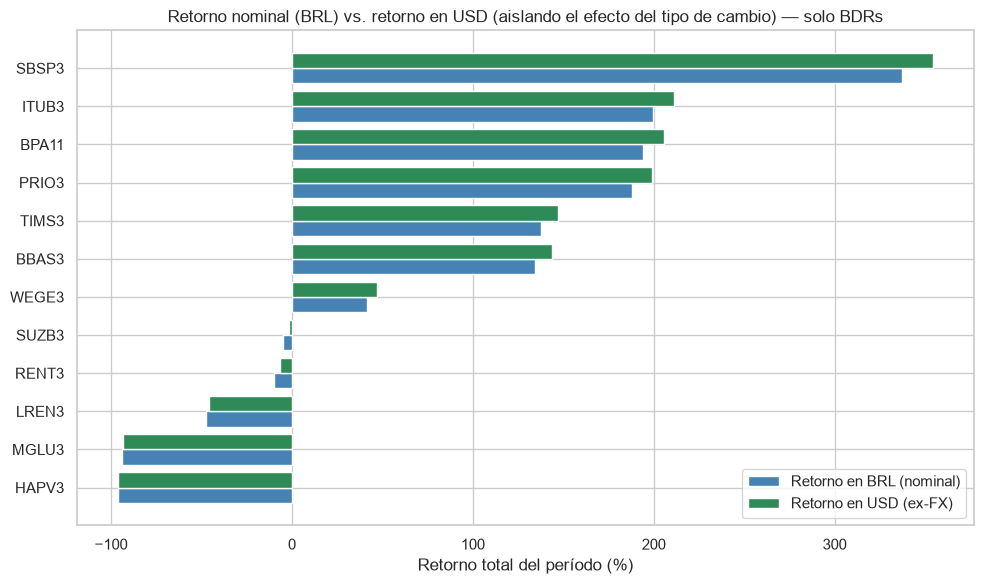

,ticker_usd,nombre_empresa,retorno_brl_pct,retorno_usdbrl_pct,retorno_usd_pct
1,SBSP3,Cia De Saneamiento Basi,337.3,-3.8,354.5
9,ITUB3,Banco Itau Unibanco Sa,199.4,-3.8,211.1
6,BPA11,Banco Btg Pactual S.A,194.3,-3.8,205.9
3,PRIO3,Petro Rio S.A,187.8,-3.8,199.1
5,TIMS3,Tim S.A,137.7,-3.8,147.1
2,BBAS3,Banco Do Brasil S.A,134.3,-3.8,143.5
7,WEGE3,Weg S.A,41.5,-3.8,47.1
8,SUZB3,Suzano S.A,-5.2,-3.8,-1.4
10,RENT3,Localiza Rent A Car S.A,-10.0,-3.8,-6.5
11,LREN3,Lojas Renner S.A,-47.8,-3.8,-45.7


In [5]:
q_fx = """
WITH rango AS (
    SELECT
        GREATEST((SELECT MIN(fecha) FROM fact_precios_daily WHERE ticker_usd = ANY(?) AND adj_close IS NOT NULL),
                 (SELECT MIN(fecha) FROM fact_macro_daily WHERE serie = 'USDBRL')) AS inicio,
        LEAST((SELECT MAX(fecha) FROM fact_precios_daily WHERE ticker_usd = ANY(?) AND adj_close IS NOT NULL),
              (SELECT MAX(fecha) FROM fact_macro_daily WHERE serie = 'USDBRL')) AS fin
),
precios_ticker AS (
    SELECT p.ticker_usd,
           FIRST(p.adj_close ORDER BY p.fecha) AS p_inicial,
           LAST(p.adj_close ORDER BY p.fecha) AS p_final
    FROM fact_precios_daily p, rango r
    WHERE p.ticker_usd = ANY(?) AND p.adj_close IS NOT NULL
      AND p.fecha BETWEEN r.inicio AND r.fin
    GROUP BY p.ticker_usd
),
usdbrl_rango AS (
    SELECT
        FIRST(m.valor ORDER BY m.fecha) AS u_inicial,
        LAST(m.valor ORDER BY m.fecha) AS u_final
    FROM fact_macro_daily m, rango r
    WHERE m.serie = 'USDBRL' AND m.fecha BETWEEN r.inicio AND r.fin
)
SELECT
    pt.ticker_usd,
    ROUND((pt.p_final / pt.p_inicial - 1) * 100, 1) AS retorno_brl_pct,
    ROUND((u.u_final / u.u_inicial - 1) * 100, 1) AS retorno_usdbrl_pct,
    ROUND(((pt.p_final / pt.p_inicial) / (u.u_final / u.u_inicial) - 1) * 100, 1) AS retorno_usd_pct
FROM precios_ticker pt, usdbrl_rango u
"""
retorno_fx = con.execute(q_fx, [BDR_TICKERS, BDR_TICKERS, BDR_TICKERS]).fetchdf().merge(
    dim_brasil[["ticker_usd", "nombre_empresa"]], on="ticker_usd"
)
retorno_fx = retorno_fx.sort_values("retorno_usd_pct", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(retorno_fx))
ax.barh([i + 0.2 for i in x], retorno_fx["retorno_brl_pct"], height=0.4, label="Retorno en BRL (nominal)", color="steelblue")
ax.barh([i - 0.2 for i in x], retorno_fx["retorno_usd_pct"], height=0.4, label="Retorno en USD (ex-FX)", color="seagreen")
ax.set_yticks(list(x))
ax.set_yticklabels(retorno_fx["ticker_usd"])
ax.invert_yaxis()
ax.set_xlabel("Retorno total del período (%)")
ax.set_title("Retorno nominal (BRL) vs. retorno en USD (aislando el efecto del tipo de cambio) — solo BDRs")
ax.legend()
plt.tight_layout()
plt.show()

retorno_fx[["ticker_usd", "nombre_empresa", "retorno_brl_pct", "retorno_usdbrl_pct", "retorno_usd_pct"]]

## 5. Exposición macro: correlación vs. dólar y vs. Bovespa

Correlación del retorno DIARIO de cada una de las 32 empresas (BDR y ADR directo por igual — acá sí aplica a ambos grupos, da igual en qué moneda cotice el precio) contra el cambio diario de `USDBRL` y contra el retorno diario de `BOVESPA` — mismo método que `gold/macro_sensitivity.py` (correlación de Pearson con `CORR()` de DuckDB), aplicado acá a las dos series relevantes para Brasil en vez de la tasa. Queda como query ad-hoc en la notebook, no como vista persistente — si en el futuro sirve para otro análisis, se promueve a `gold/`.

Lectura esperada: correlación alta y positiva contra Bovespa (son parte del índice, deberían moverse juntas) y correlación negativa contra USDBRL (cuando el dólar sube contra el real -suele ser salida de capitales/risk-off en emergentes- las acciones locales tienden a caer).

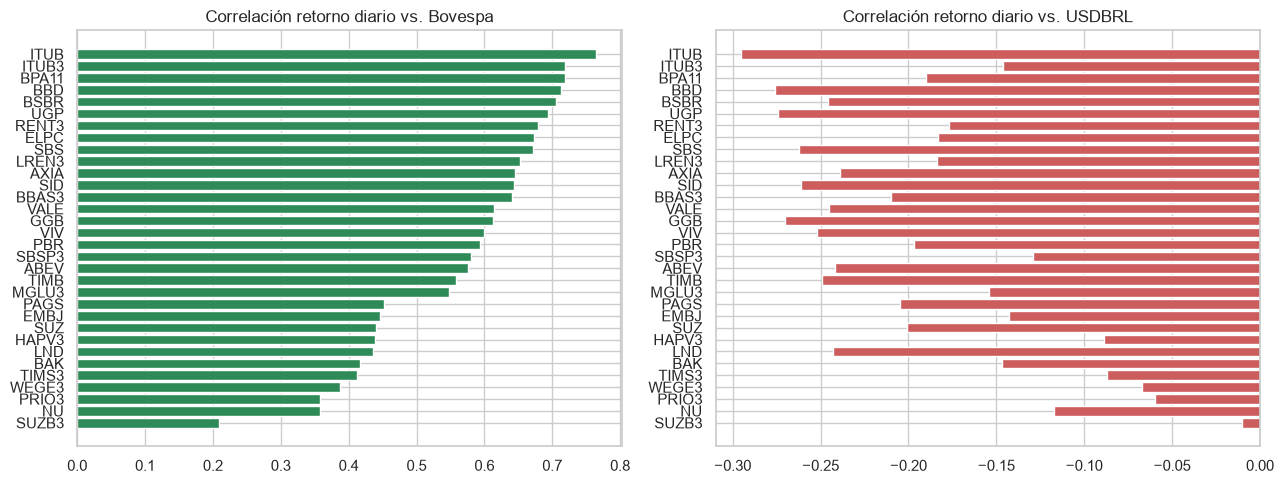

,ticker_usd,nombre_empresa,corr_vs_bovespa,corr_vs_usdbrl,dias_muestra
29,ITUB,Itau Unibanco Holding Sa,0.764,-0.295,898
1,ITUB3,Banco Itau Unibanco Sa,0.719,-0.146,916
5,BPA11,Banco Btg Pactual S.A,0.719,-0.190,916
7,BBD,Banco Bradesco S.A,0.713,-0.276,898
25,BSBR,Banco Santander (Brasil),0.705,-0.246,898
22,UGP,Ultrapar Participagues,0.693,-0.274,898
2,RENT3,Localiza Rent A Car S.A,0.679,-0.177,916
14,ELPC,Copel,0.673,-0.183,494
0,SBS,Cia Sabesp,0.671,-0.262,898
23,LREN3,Lojas Renner S.A,0.652,-0.184,916


In [6]:
q_corr = """
WITH retornos_ticker AS (
    SELECT ticker_usd, fecha,
           adj_close / LAG(adj_close) OVER (PARTITION BY ticker_usd ORDER BY fecha) - 1 AS retorno
    FROM fact_precios_daily
    WHERE ticker_usd = ANY(?) AND adj_close IS NOT NULL
),
macro_wide AS (
    SELECT fecha,
           MAX(CASE WHEN serie = 'USDBRL' THEN valor END) AS usdbrl,
           MAX(CASE WHEN serie = 'BOVESPA' THEN valor END) AS bovespa
    FROM fact_macro_daily WHERE serie IN ('USDBRL', 'BOVESPA')
    GROUP BY fecha
),
macro_retornos AS (
    SELECT fecha,
           usdbrl / LAG(usdbrl) OVER (ORDER BY fecha) - 1 AS ret_usdbrl,
           bovespa / LAG(bovespa) OVER (ORDER BY fecha) - 1 AS ret_bovespa
    FROM macro_wide
)
SELECT
    r.ticker_usd,
    COUNT(*) AS dias_muestra,
    ROUND(CORR(r.retorno, m.ret_usdbrl), 3) AS corr_vs_usdbrl,
    ROUND(CORR(r.retorno, m.ret_bovespa), 3) AS corr_vs_bovespa
FROM retornos_ticker r
JOIN macro_retornos m USING (fecha)
WHERE r.retorno IS NOT NULL AND m.ret_usdbrl IS NOT NULL AND m.ret_bovespa IS NOT NULL
GROUP BY r.ticker_usd
"""
exposicion = con.execute(q_corr, [BRASIL]).fetchdf().merge(dim_brasil[["ticker_usd", "nombre_empresa"]], on="ticker_usd")
exposicion = exposicion.sort_values("corr_vs_bovespa", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh(exposicion["ticker_usd"], exposicion["corr_vs_bovespa"], color="seagreen")
axes[0].set_title("Correlación retorno diario vs. Bovespa")
axes[0].invert_yaxis()
axes[1].barh(exposicion["ticker_usd"], exposicion["corr_vs_usdbrl"], color="indianred")
axes[1].set_title("Correlación retorno diario vs. USDBRL")
axes[1].axvline(0, color="grey", linewidth=0.8)
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

exposicion[["ticker_usd", "nombre_empresa", "corr_vs_bovespa", "corr_vs_usdbrl", "dias_muestra"]]

## 6. Ranking final

Cruza todo lo de arriba: checklist de Lynch, cuán barata está vs. su sector real, y (donde aplica) cuánto le pegó/ayudó el tipo de cambio en el período. `retorno_usd_pct` queda vacío para los ADR directos (no les aplica ese ajuste, ver sección 4). `vehiculo`/`duplica_de` para no leer como 4 empresas distintas lo que son 2 empresas vistas por 2 vehículos.

In [7]:
ranking = (
    lynch_brasil[["ticker_usd", "nombre_empresa", "lynch_categoria_auto", "lynch_checklist_score", "lynch_valuacion_peg"]]
    .merge(dim_brasil[["ticker_usd", "vehiculo", "duplica_de"]], on="ticker_usd")
    .merge(comparables_brasil[["ticker_usd", "comp_pe_vs_sector_pct", "comp_percentil_crecimiento_en_sector"]], on="ticker_usd")
    .merge(retorno_fx[["ticker_usd", "retorno_usd_pct"]], on="ticker_usd", how="left")
    .merge(exposicion[["ticker_usd", "corr_vs_bovespa", "corr_vs_usdbrl"]], on="ticker_usd")
    .sort_values(["lynch_checklist_score", "comp_pe_vs_sector_pct"], ascending=[False, True])
)
ranking

,ticker_usd,nombre_empresa,lynch_categoria_auto,lynch_checklist_score,lynch_valuacion_peg,vehiculo,duplica_de,comp_pe_vs_sector_pct,comp_percentil_crecimiento_en_sector,retorno_usd_pct,corr_vs_bovespa,corr_vs_usdbrl
21,PAGS,Pagseguro Digital Ltd,Estable,3,Sin dato,ADR directo,NaN,-54.3,52.0,NaN,0.452,-0.205
26,VIV,Telefonica Brasil S.A,Estable,3,Barata,ADR directo,NaN,-4.8,38.0,NaN,0.599,-0.252
14,GGB,Gerdau S.A,Recuperable,3,Sin dato,ADR directo,NaN,41.0,43.0,NaN,0.613,-0.270
19,MGLU3,Magazine Luiza S.A,Recuperable,3,Sin dato,BDR,NaN,258.2,29.0,-93.5,0.548,-0.154
7,LND,Brasilagro Com,Recuperable,3,Sin dato,ADR directo,NaN,NaN,7.0,NaN,0.436,-0.243
11,SID,Companhia Siderurgica Nacional,Recuperable,3,Sin dato,ADR directo,NaN,NaN,36.0,NaN,0.643,-0.261
15,HAPV3,Hapvida Participacoes I Investimentos Sa,Recuperable,3,Sin dato,BDR,NaN,NaN,57.0,-96.0,0.439,-0.089
27,TIMB,Tim Participacoes S.A,Bajo Crecimiento,2,Razonable,ADR directo,TIMS3,-32.5,31.0,NaN,0.558,-0.249
0,ABEV,Ambev S.A,Bajo Crecimiento,2,Cara,ADR directo,NaN,-27.2,40.0,NaN,0.576,-0.242
4,BBAS3,Banco Do Brasil S.A,Recuperable,2,Sin dato,BDR,NaN,-20.7,25.0,143.5,0.641,-0.210
